This notebook aims to analyze EFO vs NLP embeddings

the main hypothesis is that NLP embeddings may capture better trait -> related-measurement similarity


In [2]:
import polars as pl
import pandas as pd 
import pickle
import os, sys
import numpy as np

from scipy.spatial.distance import cosine, pdist
from scipy.stats import percentileofscore

from sklearn.metrics import pairwise_distances

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from network import knn_graph

import networkx as nx

In [3]:
# traits with at least one genetic association 
with open("../aux_data/traits_geq_oneGenAssoc.pkl","rb") as file:
    traits = pickle.load(file)

In [4]:
disease_ot = pl.read_parquet("../data/disease/disease.parquet")
disease_ot = disease_ot.filter(pl.col("id").is_in(traits))
disease_ot.head(1)

id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,narrowSynonyms,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms
str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],struct[3],struct[4]
"""DOID_10113""","""http://purl.obolibrary.org/obo…","""trypanosomiasis""","""Infection with protozoa of the…","[""DOID:10113"", ""ICD10CM:B56"", … ""UMLS:C0041227""]","[""MONDO_0002428""]","[""Trypanosoma caused disease or disorder"", ""Trypanosoma disease or disorder"", … ""trypanosomiasis""]","[""Trypanosomiases""]",[],[],[],[],"[""MONDO_0001444"", ""EFO_0005225"", ""EFO_0008559""]","[""MONDO_0002428"", ""EFO_0001067"", ""EFO_0005741""]","[""EFO_0005741""]","[""MONDO_0001444"", ""EFO_0005225"", … ""EFO_0005529""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_10113"",""DOID_10113""}}","{[""Trypanosoma caused disease or disorder"", ""Trypanosoma disease or disorder"", … ""trypanosomiasis""],[""Trypanosomiases""],[],[]}"


In [5]:
efo_embeddings = pd.read_parquet("../data/efo_embeddings/embeddings.parquet")

efo_embeddings = efo_embeddings.merge(
    disease_ot.to_pandas(),
    left_on='iri',
    right_on='code',
    validate='one_to_one',
    how='inner'
)

efo_embeddings = efo_embeddings[efo_embeddings['id'].isin(traits)].reset_index(drop=True)
efo_embeddings["row_nr"] = efo_embeddings.index
efo_embeddings.head(1)

,iri,embeddings,id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,...,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms,row_nr
0,http://purl.obolibrary.org/obo/DOID_10113,"[0.027114742, -0.0390197, -0.017756714, -0.067...",DOID_10113,http://purl.obolibrary.org/obo/DOID_10113,trypanosomiasis,Infection with protozoa of the genus trypanosoma.,"[DOID:10113, ICD10CM:B56, ICD9:086, ICD9:086.9...",[MONDO_0002428],"[Trypanosoma caused disease or disorder, Trypa...",[Trypanosomiases],...,[],[],[],"[MONDO_0001444, EFO_0005225, EFO_0008559]","[MONDO_0002428, EFO_0001067, EFO_0005741]",[EFO_0005741],"[MONDO_0001444, EFO_0005225, EFO_0008559, EFO_...","{'isTherapeuticArea': False, 'leaf': False, 's...",{'hasExactSynonym': ['Trypanosoma caused disea...,0


In [6]:
disease_embeddings = pl.read_parquet("../output/id_value_embeddings.parquet")
disease_embeddings.head(1)

id,variable,value,embeddings
str,str,str,"array[f32, 768]"
"""DOID_10113""","""name""","""trypanosomiasis""","[-0.827013, -0.04076, … 0.280557]"


In [7]:
disease_embeddings.shape

(55152, 4)

In [8]:
# synonyms embeddings:
embedding_map = dict(zip(disease_embeddings["value"].to_list(), disease_embeddings["embeddings"].to_list()))

In [9]:
len(embedding_map.items())

54032

In [10]:
disease_ot_synonyms = (
    disease_ot
    .explode(pl.col("exactSynonyms"))  # Explode synonyms into separate rows
    .select(['id', 'name', 'exactSynonyms'])  # Keep necessary columns
    .filter(pl.col("name") != pl.col("exactSynonyms"))  # Remove rows where name == synonym
    .unique(subset=['name', 'exactSynonyms'], keep='first', maintain_order=True)  # Remove duplicates
)

In [11]:
disease_ot_synonyms.head(1)

id,name,exactSynonyms
str,str,str
"""DOID_10113""","""trypanosomiasis""","""Trypanosoma caused disease or …"


In [12]:
# add embedding-derived cosine distance between synonyms
disease_ot_synonyms = (
    disease_ot_synonyms
    .with_columns(
        pl.struct('name','exactSynonyms')
        .map_elements(
            lambda x: cosine(embedding_map[x['name']],embedding_map[x['exactSynonyms']]),
            return_dtype=pl.Float64
        ).alias('cosine_dist')
    )
)

In [13]:
# distribution of cosine distances between synonyms 
synonyms_distances = disease_ot_synonyms['cosine_dist'].to_list()
print(f"Number of synonym couples with dist: {len(synonyms_distances)}")

Number of synonym couples with dist: 38910


In [14]:
deciles = np.quantile(synonyms_distances, q=np.arange(0.1, 1., 0.1))
for i,v in enumerate(deciles):
    print(f"Decile {i}: {v:.2f}")

Decile 0: 0.02
Decile 1: 0.05
Decile 2: 0.08
Decile 3: 0.12
Decile 4: 0.17
Decile 5: 0.22
Decile 6: 0.27
Decile 7: 0.34
Decile 8: 0.45


In [15]:
rng = np.random.default_rng(42)

random_distances = pdist(
      rng.choice(disease_embeddings["embeddings"], size=450, replace=False),
      metric='cosine',
)

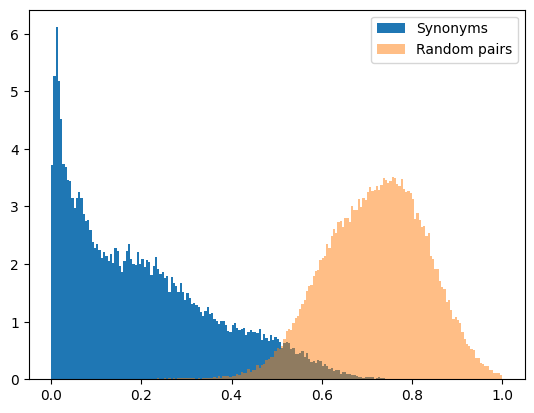

In [16]:
# Use a constant bin width to make the two histograms easier to compare visually
bin_width = 0.005
bins = np.arange(0, 1 + bin_width, bin_width)

fig, ax = plt.subplots()

# Plot the first histogram
ax.hist(
    synonyms_distances, 
    bins=bins, 
    label="Synonyms", 
    density=True
)

ax.hist(
    random_distances,
    bins=bins, 
    label="Random pairs", 
    density=True,
    alpha=0.5
)

ax.legend()

plt.show()

In [17]:
disease_ot_with_embeddings = (
    disease_ot
    .with_columns(
        pl.struct('id','name').map_elements(
            lambda t: embedding_map[t['name']],
            return_dtype=pl.Array(inner=pl.Float32, shape=768)
        ).alias("embeddings")
    )
)
disease_ot_with_embeddings = disease_ot_with_embeddings.with_row_index("row_nr")

In [18]:
disease_ot_with_embeddings.head(2)

row_nr,id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,narrowSynonyms,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms,embeddings
u32,str,str,str,str,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str],struct[3],struct[4],"array[f32, 768]"
0,"""DOID_10113""","""http://purl.obolibrary.org/obo…","""trypanosomiasis""","""Infection with protozoa of the…","[""DOID:10113"", ""ICD10CM:B56"", … ""UMLS:C0041227""]","[""MONDO_0002428""]","[""Trypanosoma caused disease or disorder"", ""Trypanosoma disease or disorder"", … ""trypanosomiasis""]","[""Trypanosomiases""]",[],[],[],[],"[""MONDO_0001444"", ""EFO_0005225"", ""EFO_0008559""]","[""MONDO_0002428"", ""EFO_0001067"", ""EFO_0005741""]","[""EFO_0005741""]","[""MONDO_0001444"", ""EFO_0005225"", … ""EFO_0005529""]","{false,false,{""http://purl.obolibrary.org/obo/DOID_10113"",""DOID_10113""}}","{[""Trypanosoma caused disease or disorder"", ""Trypanosoma disease or disorder"", … ""trypanosomiasis""],[""Trypanosomiases""],[],[]}","[-0.827013, -0.04076, … 0.280557]"
1,"""GO_0002524""","""http://purl.obolibrary.org/obo…","""hypersensitivity""","""An inflammatory response to an…","[""Wikipedia:Hypersensitivity""]","[""GO_0002376"", ""GO_0002526""]",[],"[""hypersensitivity response""]",[],[],[],[],"[""GO_0001802"", ""GO_0001806"", … ""GO_0016068""]","[""GO_0002376"", ""GO_0002526"", … ""GO_0050896""]","[""GO_0008150""]","[""GO_0001802"", ""GO_0001806"", … ""GO_0016068""]","{false,false,{""http://purl.obolibrary.org/obo/GO_0002524"",""GO_0002524""}}","{[],[""hypersensitivity response""],[],[]}","[-0.251358, -0.265389, … 0.429993]"


In [19]:
# calculate pairwise distances - NLP
p_distances_nlp = pairwise_distances(disease_ot_with_embeddings['embeddings'].to_list()[:], metric='cosine')

In [20]:
# calculate pairwise distances - EFO
p_distances_efo = pairwise_distances(efo_embeddings['embeddings'].to_list()[:], metric='cosine')

In [21]:
dist_distances_nlp = p_distances_nlp[np.triu_indices(p_distances_nlp.shape[0])]
dist_distances_efo = p_distances_efo[np.triu_indices(p_distances_efo.shape[0])]

In [22]:
deciles = np.quantile(dist_distances_nlp, q=np.arange(0.1, 1., 0.1))
for i,v in enumerate(deciles):
    print(f"Decile {i}: {v:.2f}")

Decile 0: 0.58
Decile 1: 0.63
Decile 2: 0.66
Decile 3: 0.68
Decile 4: 0.71
Decile 5: 0.73
Decile 6: 0.76
Decile 7: 0.79
Decile 8: 0.83


In [23]:
deciles = np.quantile(dist_distances_efo, q=np.arange(0.1, 1., 0.1))
for i,v in enumerate(deciles):
    print(f"Decile {i}: {v:.2f}")

Decile 0: 0.11
Decile 1: 0.14
Decile 2: 0.17
Decile 3: 0.19
Decile 4: 0.21
Decile 5: 0.23
Decile 6: 0.25
Decile 7: 0.29
Decile 8: 0.35


In [24]:
efo_embeddings.head(1)

,iri,embeddings,id,code,name,description,dbXRefs,parents,exactSynonyms,relatedSynonyms,...,broadSynonyms,obsoleteTerms,obsoleteXRefs,children,ancestors,therapeuticAreas,descendants,ontology,synonyms,row_nr
0,http://purl.obolibrary.org/obo/DOID_10113,"[0.027114742, -0.0390197, -0.017756714, -0.067...",DOID_10113,http://purl.obolibrary.org/obo/DOID_10113,trypanosomiasis,Infection with protozoa of the genus trypanosoma.,"[DOID:10113, ICD10CM:B56, ICD9:086, ICD9:086.9...",[MONDO_0002428],"[Trypanosoma caused disease or disorder, Trypa...",[Trypanosomiases],...,[],[],[],"[MONDO_0001444, EFO_0005225, EFO_0008559]","[MONDO_0002428, EFO_0001067, EFO_0005741]",[EFO_0005741],"[MONDO_0001444, EFO_0005225, EFO_0008559, EFO_...","{'isTherapeuticArea': False, 'leaf': False, 's...",{'hasExactSynonym': ['Trypanosoma caused disea...,0


In [25]:
def compare_embedding_distances(trait1, trait2):

    # dist_distances_nlp
    # dist_distances_efo
    
    row1_nlp = disease_ot_with_embeddings.filter(pl.col("name") == trait1)
    row2_nlp = disease_ot_with_embeddings.filter(pl.col("name") == trait2)

    row1_nlp_idx = row1_nlp['row_nr'].to_list()[0]
    row2_nlp_idx = row2_nlp['row_nr'].to_list()[0]

    row1_nlp_iri = row1_nlp['code'].to_list()[0]
    row2_nlp_iri = row2_nlp['code'].to_list()[0]
    
    row1_efo = efo_embeddings[efo_embeddings['iri']==row1_nlp_iri]
    row2_efo = efo_embeddings[efo_embeddings['iri']==row2_nlp_iri]

    emb1 = row1_efo['embeddings'].to_list()[0]
    emb2 = row2_efo['embeddings'].to_list()[0]
    
    row1_efo_idx = row1_efo['row_nr'].to_list()[0]
    row2_efo_idx = row2_efo['row_nr'].to_list()[0]

    nlp_cosine = p_distances_nlp[row1_nlp_idx,row2_nlp_idx]
    efo_cosine = p_distances_efo[row1_efo_idx,row2_efo_idx]

    percentile_nlp = percentileofscore(dist_distances_nlp, nlp_cosine)
    percentile_efo = percentileofscore(dist_distances_efo, efo_cosine)

    print(f"NLP: {nlp_cosine}")
    print(f"EFO: {efo_cosine}")

    print(f"NLP perc: {percentile_nlp}")
    print(f"EFO perc: {percentile_efo}")




In [26]:
compare_embedding_distances('obesity','body mass index')

NLP: 0.26122258213103056
EFO: 0.3396183252334595
NLP perc: 0.10836604271493823
EFO perc: 88.83207249448321


In [27]:
compare_embedding_distances('glucose measurement','type 2 diabetes mellitus')

NLP: 0.5380454940500149
EFO: 0.5425523519515991
NLP perc: 4.833276366204159
EFO perc: 99.09774248618199


In [28]:
compare_embedding_distances('anemia','hemoglobin measurement')

NLP: 0.42916163539026364
EFO: 0.47645705938339233
NLP perc: 0.6663482511553782
EFO perc: 97.83515849889793


In [29]:
compare_embedding_distances('Hypercholesterolemia','free cholesterol in large LDL measurement')

NLP: 0.4900392398923993
EFO: 0.15312618017196655
NLP perc: 1.9526795978297318
EFO perc: 24.634477725594742


In [30]:
compare_embedding_distances("Crohn's disease",'ulcerative colitis')

NLP: 0.217791971975984
EFO: 0.02216935157775879
NLP perc: 0.07278935224958906
EFO perc: 1.5600627803614577


In [31]:
compare_embedding_distances("Alzheimer disease",'beta-amyloid 1-42 measurement')

NLP: 0.43542899584714145
EFO: 0.33785849809646606
NLP perc: 0.7371968774659681
EFO perc: 88.60740996606589


In [32]:
compare_embedding_distances("kidney disease",'serum creatinine amount')

NLP: 0.7520771898856389
EFO: 0.2928367257118225
NLP perc: 67.90171584659511
EFO perc: 80.98105523227939


In [33]:
compare_embedding_distances("Parkinson disease",'kidney disease')

NLP: 0.6932049652307066
EFO: 0.49523383378982544
NLP perc: 43.71059430842849
EFO perc: 98.30456514157676


In [34]:
compare_embedding_distances("multiple sclerosis",'multiple sclerosis symptom measurement')

NLP: 0.2847963715778815
EFO: 0.2769191861152649
NLP perc: 0.13075261965972207
EFO perc: 77.10686326129458


In [35]:
compare_embedding_distances("hypertension",'Elevated systolic blood pressure')

NLP: 0.30030213350396406
EFO: 0.2992023229598999
NLP perc: 0.14826691316312
EFO perc: 82.32435749860835


In [36]:
compare_embedding_distances("Iron deficiency anemia",'ferritin measurement')

NLP: 0.5276077231109372
EFO: 0.13589215278625488
NLP perc: 3.977968121044411
EFO perc: 17.539944442019802


In [37]:
compare_embedding_distances("Alzheimer disease",'t-tau measurement')

NLP: 0.5970390524561588
EFO: 0.33666276931762695
NLP perc: 13.303565629813367
EFO perc: 88.45199079553109


In [38]:
compare_embedding_distances("neuropathy","peripheral neuropathy")

NLP: 0.07946422745518666
EFO: 0.22445213794708252
NLP perc: 0.015852546918129862
EFO perc: 58.19623450194828


In [39]:
# filter efo embeddings for traits 
compare_embedding_distances("neuropathy","Chronic pain")

NLP: 0.4883876941017149
EFO: 0.34122931957244873
NLP perc: 1.8928665760089902
EFO perc: 89.03432797736187


In [40]:
# 5th percentile of NLP
def get_similar_at_threshold(name, percentile=0.05):

    fifth_perc = np.quantile(dist_distances_nlp, q=percentile)
    # ('glucose measurement','type 2 diabetes mellitus')
    # take all the elements at 5fth perc distance from name
    row1_nlp = disease_ot_with_embeddings.filter(pl.col("name") == name)
    row1_nlp_idx = row1_nlp['row_nr'].to_list()[0]
    nlp_cosine = p_distances_nlp[row1_nlp_idx,:]
    similars = np.where(nlp_cosine <= fifth_perc)[0]

    for s in similars:
        str_similar = disease_ot_with_embeddings[int(s)]['name'].to_list()[0]
        print(f"{str_similar}")


In [41]:
disease_ot_with_embeddings.height

16242

In [42]:
get_similar_at_threshold(name='glucose measurement', percentile=0.005)
    

Glucose intolerance
Glycosuria
Abnormal glucose homeostasis
glucose homeostasis trait
blood glucose amount
glucose tolerance test
insulin measurement
glucose measurement
glycoprotein measurement
carbohydrate measurement
hexose measurement
1,5 anhydroglucitol measurement
glucose-dependent insulinotropic peptide measurement
sugar consumption measurement
glucuronate measurement
glucose change measurement
glycerate measurement
glucose-to-mannose ratio
Maltose measurement
methyl glucopyranoside (alpha + beta) measurement
ethyl beta-glucopyranoside measurement
gluconate measurement
glucokinase measurement


In [43]:
get_similar_at_threshold(name='neuropathy', percentile=0.01)

Abnormality of the nervous system
Sensory neuropathy
Neurodegeneration
Paraparesis
EMG: neuropathic changes
Paralysis
Motor axonal neuropathy
Sensorimotor neuropathy
Peripheral demyelination
Abnormal central motor function
nervous system benign neoplasm
autonomic neuropathy
diabetic polyneuropathy
optic nerve disorder
sensory peripheral neuropathy
radiculopathy
demyelinating polyneuropathy
cranial nerve neuropathy
axonal neuropathy
hereditary motor and sensory neuropathy
Charcot-Marie-Tooth disease
neuralgic amyotrophy
paraneoplastic neurologic syndrome
hereditary peripheral neuropathy
auditory neuropathy
peripheral neuropathy, autosomal recessive, with or without impaired intellectual development
neuropathy, small fiber
nervous system disease
peripheral neuropathy
motor neuron disease
neuropathy
neurotic disorder
conduction system disorder
neurodegenerative disease
nervous system cancer
optic neuritis
central nervous system disease
peripheral nervous system disease
spinal cord disease

In [44]:

thresh_2_5_perc = np.quantile(dist_distances_nlp, q=0.025)
thresh_1_perc = np.quantile(dist_distances_nlp, q=0.01)
thresh_0_5_perc = np.quantile(dist_distances_nlp, q=0.005)
thresh_0_25_perc = np.quantile(dist_distances_nlp, q=0.0025)

print(f"Threshold at 2.5%: {thresh_2_5_perc}")
print(f"Threshold at 1%: {thresh_1_perc}")
print(f"Threshold at 0.5%: {thresh_0_5_perc}")
print(f"Threshold at 0.25%: {thresh_0_25_perc}")


Threshold at 2.5%: 0.5031089068273015
Threshold at 1%: 0.45343649063644087
Threshold at 0.5%: 0.4103284496732533
Threshold at 0.25%: 0.35545953185660134


In [49]:
def create_network(threhsold):
    G = nx.from_numpy_array(
        p_distances_nlp < threhsold, 
        nodelist=disease_ot_with_embeddings['id'].to_list()
    )
    G.remove_edges_from(nx.selfloop_edges(G))
    return(list(G.edges()))


In [50]:
G_thresh_2_5_perc = create_network(thresh_2_5_perc)
G_thresh_1_perc = create_network(thresh_1_perc)
G_thresh_0_5_perc = create_network(thresh_0_5_perc)
G_thresh_0_25_perc = create_network(thresh_0_25_perc)

In [52]:
with open("../output/trait_trait_edges_2_5.pkl","wb") as file:
    pickle.dump(G_thresh_2_5_perc, file)
with open("../output/trait_trait_edges_1.pkl","wb") as file:
    pickle.dump(G_thresh_1_perc, file)
with open("../output/trait_trait_edges_0_5.pkl","wb") as file:
    pickle.dump(G_thresh_0_5_perc, file)
with open("../output/trait_trait_edges_0_25.pkl","wb") as file:
    pickle.dump(G_thresh_0_25_perc, file)